<a href="https://colab.research.google.com/github/gunjanak/Discrete_Mathematics_Python/blob/main/Lab_X_Dijkstra_Kruskal_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Shortest Path Using Dijkstra

/usr/local/lib/python3.12/dist-packages/matplotlib/animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


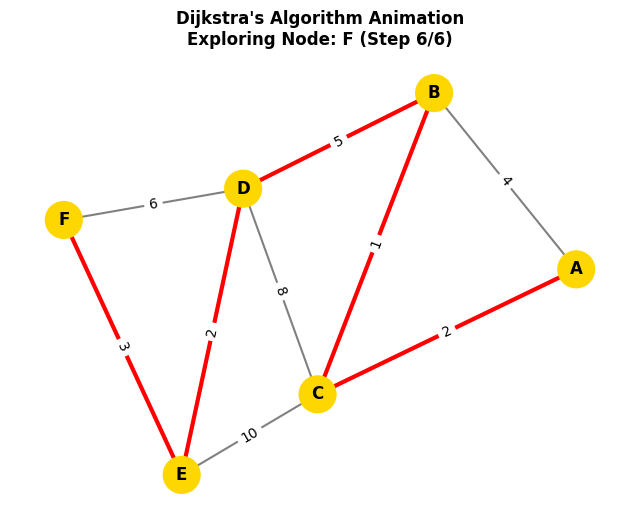

Dijkstra animation generated successfully!


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import heapq

# --- Step 1: Create a Weighted Graph ---.
G = nx.Graph()
edges = [
    ('A', 'B', 4), ('A', 'C', 2),
    ('B', 'C', 1), ('B', 'D', 5),
    ('C', 'D', 8), ('C', 'E', 10),
    ('D', 'E', 2), ('D', 'F', 6),
    ('E', 'F', 3)
]
G.add_weighted_edges_from(edges)

source, target = 'A', 'F'

# --- Step 2: Dijkstra's Algorithm with Step Recording ---
def dijkstra_steps(graph, start, end):
    distances = {node: float('inf') for node in graph.nodes()}
    distances[start] = 0
    previous_nodes = {node: None for node in graph.nodes()}
    pq = [(0, start)]

    visited = set()
    frames = [] # To store states for animation

    while pq:
        current_dist, current_node = heapq.heappop(pq)

        if current_node in visited:
            continue
        visited.add(current_node)

        # Record state for animation (visited nodes, current node, current distances)
        frames.append({
            'visited': set(visited),
            'current': current_node,
            'distances': dict(distances)
        })

        if current_node == end:
            break

        for neighbor, data in graph[current_node].items():
            weight = data['weight']
            distance = current_dist + weight

            if distance < distances[neighbor]:
                distances[neighbor] = distance
                previous_nodes[neighbor] = current_node
                heapq.heappush(pq, (distance, neighbor))

    # Reconstruct shortest path
    path = []
    curr = end
    while curr is not None:
        path.insert(0, curr)
        curr = previous_nodes[curr]

    return frames, path if distances[end] != float('inf') else []

frames, shortest_path = dijkstra_steps(G, source, target)

# --- Step 3: Animate the Algorithm using Matplotlib ---
pos = nx.spring_layout(G, seed=42) # Consistent node positioning
fig, ax = plt.subplots(figsize=(8, 6))

def update(frame_idx):
    ax.clear()
    state = frames[frame_idx]
    visited_nodes = state['visited']
    current_node = state['current']

    # Define node colors based on state
    node_colors = []
    for node in G.nodes():
        if node == source:
            node_colors.append('limegreen') # Start node
        elif node == current_node:
            node_colors.append('orange')    # Currently exploring node
        elif node in visited_nodes:
            node_colors.append('skyblue')   # Visited node
        else:
            node_colors.append('lightgray') # Unvisited node

    # Highlight final path if we reached the last frame
    path_edges = []
    if frame_idx == len(frames) - 1 and shortest_path:
        path_edges = list(zip(shortest_path[:-1], shortest_path[1:]))
        for i, node in enumerate(shortest_path):
            idx = list(G.nodes()).index(node)
            node_colors[idx] = 'gold'

    edge_colors = ['red' if (u, v) in path_edges or (v, u) in path_edges else 'gray' for u, v in G.edges()]
    edge_widths = [3 if (u, v) in path_edges or (v, u) in path_edges else 1.5 for u, v in G.edges()]

    # Draw graph elements
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=700)
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color=edge_colors, width=edge_widths)
    nx.draw_networkx_labels(G, pos, ax=ax, font_weight='bold')

    edge_labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, ax=ax)

    ax.set_title(f"Dijkstra's Algorithm Animation\nExploring Node: {current_node} (Step {frame_idx + 1}/{len(frames)})", fontsize=12, fontweight='bold')
    ax.axis('off')

# Create animation
ani = animation.FuncAnimation(fig, update, frames=len(frames), interval=1000, repeat=False)

# Optional: Save animation as a GIF (requires Pillow or ImageMagick)
ani.save('dijkstra_animation.gif', writer='pillow', fps=1)

plt.show()
print("Dijkstra animation generated successfully!")

# Minimum Spanning Tree using Kruskal's algorithm

/usr/local/lib/python3.12/dist-packages/matplotlib/animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


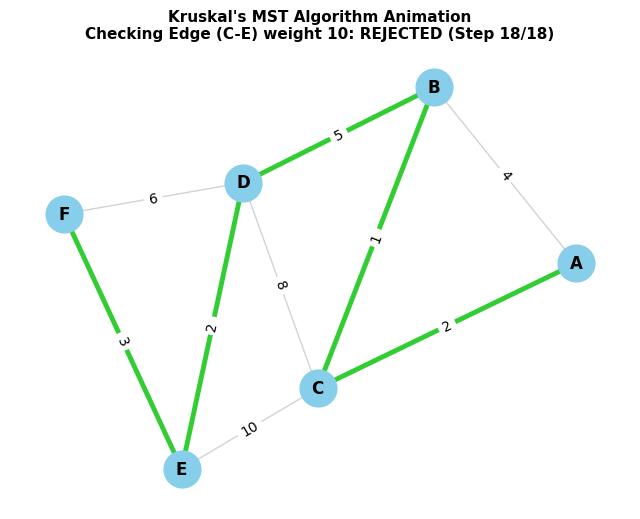

Kruskal's algorithm animation generated successfully!


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# --- Step 1: Create a Weighted Graph ---
G = nx.Graph()
edges = [
    ('A', 'B', 4), ('A', 'C', 2),
    ('B', 'C', 1), ('B', 'D', 5),
    ('C', 'D', 8), ('C', 'E', 10),
    ('D', 'E', 2), ('D', 'F', 6),
    ('E', 'F', 3)
]
G.add_weighted_edges_from(edges)

# --- Step 2: Kruskal's Algorithm with Step Recording ---
def kruskal_steps(graph):
    # Union-Find helper data structures
    parent = {}
    rank = {}

    def make_set(node):
        parent[node] = node
        rank[node] = 0

    def find(node):
        if parent[node] != node:
            parent[node] = find(parent[node])  # Path compression
        node = parent[node]
        return node

    def union(node1, node2):
        root1 = find(node1)
        root2 = find(node2)
        if root1 != root2:
            if rank[root1] < rank[root2]:
                parent[root1] = root2
            elif rank[root1] > rank[root2]:
                parent[root2] = root1
            else:
                parent[root2] = root1
                rank[root1] += 1
            return True
        return False

    for node in graph.nodes():
        make_set(node)

    # Sort edges in ascending order of weights
    sorted_edges = sorted(graph.edges(data=True), key=lambda item: item[2]['weight'])

    frames = []
    mst_edges = set()
    rejected_edges = set()

    for u, v, data in sorted_edges:
        weight = data['weight']
        # Record state before testing edge
        frames.append({
            'current_edge': (u, v),
            'weight': weight,
            'mst_edges': set(mst_edges),
            'rejected_edges': set(rejected_edges),
            'status': 'checking'
        })

        if union(u, v):
            mst_edges.add((u, v))
            status = 'accepted'
        else:
            rejected_edges.add((u, v))
            status = 'rejected'

        # Record state after evaluation
        frames.append({
            'current_edge': (u, v),
            'weight': weight,
            'mst_edges': set(mst_edges),
            'rejected_edges': set(rejected_edges),
            'status': status
        })

    return frames

frames = kruskal_steps(G)

# --- Step 3: Animate the Algorithm using Matplotlib ---
pos = nx.spring_layout(G, seed=42) # Consistent node positioning
fig, ax = plt.subplots(figsize=(8, 6))

def update(frame_idx):
    ax.clear()
    state = frames[frame_idx]
    curr_u, curr_v = state['current_edge']
    mst = state['mst_edges']
    rejected = state['rejected_edges']
    status = state['status']
    weight = state['weight']

    # Color mapping for edges
    edge_colors = []
    edge_widths = []

    for u, v in G.edges():
        edge_tuple = (u, v) if (u, v) in G.edges() else (v, u)
        if edge_tuple in mst or (v, u) in mst:
            edge_colors.append('limegreen')  # Accepted MST edge
            edge_widths.append(3.5)
        elif edge_tuple in rejected or (v, u) in rejected:
            edge_colors.append('lightgray')  # Rejected edge (forms cycle)
            edge_widths.append(1.0)
        elif (u, v) == (curr_u, curr_v) or (v, u) == (curr_u, curr_v):
            if status == 'checking':
                edge_colors.append('orange')  # Currently inspecting
                edge_widths.append(3.0)
            elif status == 'accepted':
                edge_colors.append('limegreen')
                edge_widths.append(3.5)
            else:
                edge_colors.append('red')     # Rejected on check
                edge_widths.append(2.5)
        else:
            edge_colors.append('gray')
            edge_widths.append(1.5)

    # Draw graph elements
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color='skyblue', node_size=700)
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color=edge_colors, width=edge_widths)
    nx.draw_networkx_labels(G, pos, ax=ax, font_weight='bold')

    edge_labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, ax=ax)

    status_text = f"Checking Edge ({curr_u}-{curr_v}) weight {weight}: {status.upper()}"
    ax.set_title(f"Kruskal's MST Algorithm Animation\n{status_text} (Step {frame_idx + 1}/{len(frames)})", fontsize=11, fontweight='bold')
    ax.axis('off')

# Create animation
ani = animation.FuncAnimation(fig, update, frames=len(frames), interval=1200, repeat=False)

ani.save('Kruskal_animation.gif', writer='pillow', fps=1)
plt.show()
print("Kruskal's algorithm animation generated successfully!")